# Prompt Chaining — LangChain LCEL

> "Unix pipes, ported to LLMs. Do one thing, gate it, pass it on."

This notebook implements Prompt Chaining using **LangChain Expression Language (LCEL)**:

- `prompt | model | StrOutputParser() | gate` — one step is a pipe
- a gate wrapped as a `RunnableLambda` that raises on failure
- `.with_retry(...)` — bounded gated retry, no manual loop
- `RunnablePassthrough.assign(...)` — thread every prior output forward

In the [graph version](../langgraph/tutorial.ipynb) the chain is an explicit `StateGraph`: one node per step, a gate node between each pair, a manual retry loop. Here the chain *is* the pipe. Less code, but the control flow is implicit — that is the trade-off this notebook makes visible.

Everything runs against a deterministic fake model first (no API key needed), then the real backend. Default: AI Studio + `ernie-5.1` (OpenAI-compatible). See [`.env.example`](../../../.env.example) for provider config, [`model_config.py`](../../../model_config.py) for the shared model loader.

## What this pattern does

Prompt Chaining breaks one over-stuffed prompt into a pipeline of single-purpose steps. Each step runs its own prompt against a model picked for that step, and a cheap **programmatic gate** sits between consecutive steps — a Python check, *not* an LLM call. The gate runs after a step's model call and either lets the output flow downstream or triggers a bounded retry.

The lecture's motivating incident: a content-editing agent did seven things in one prompt and published "GMV up 53%" where the source said "35%" — step 4 (fact-check) was reading step 2's mutated rewrite instead of the original draft. The fix was to split the work into independent steps with gates, and make fact-check explicitly read the **original** draft. Two named failure modes the pattern guards against:

- **Information starvation** — a downstream step can't see data an earlier step produced. Fixed by giving every step access to *all* prior outputs, not just its immediate predecessor.
- **Gate tyranny** — a too-strict gate ("exactly 500 words") rejects forever. Capped by a retry limit.

| | `langgraph/` (StateGraph) | `langchain/` (LCEL) |
|---|---|---|
| **The chain is** | Explicit nodes + edges + a manual retry loop | A `prompt \| model \| parser \| gate` pipe |
| **The gate is** | A routing node that returns to the step or advances | A `RunnableLambda` that raises `GateFailed` |
| **Bounded retry** | A `max_retries` counter in graph state | `.with_retry(stop_after_attempt=N)` |
| **Prior outputs** | Kept in a `TypedDict` state object | Accumulated by `RunnablePassthrough.assign` |
| **Trade-off** | More code, every transition visible | Less code, control flow implicit |

## Setup

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

# shared.py lives in the pattern folder (the parent dir); model_config.py and
# nbtools.py at the repo root. Find each by walking up, so the notebook isn't
# tied to a fixed folder depth (no brittle "../../.." counting).
for _marker in ("shared.py", "model_config.py", "nbtools.py"):
    _dir = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / _marker).exists())
    sys.path.insert(0, str(_dir))

# LCEL building blocks
from langchain_core.runnables import RunnableLambda, RunnablePassthrough
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

# Shared model loader, gate factories, and graph renderer (same modules the langgraph/ notebook uses)
from model_config import get_model
from shared import length_gate, starts_with_gate
from nbtools import show_graph

In [2]:
# Load the configured LLM — defaults to ernie:ernie-5.1. Returns None if no API key.
model = get_model()

Model: ernie:ernie-5.1


## The gate as a Runnable

A gate is the heart of the pattern: a cheap programmatic check that runs *after* a step's model call. In LCEL there is no place to put an `if` between two piped runnables — so we make the gate itself a runnable.

`make_gate_runnable` wraps a gate config (`{"name", "fn", "description"}` from [`shared.py`](../shared.py)) into a `RunnableLambda` that:

- returns its input **unchanged** when the gate passes — so it slots into a pipe transparently, and
- raises `GateFailed` when the gate fails — so `.with_retry(...)` can re-run the step.

Raising on failure is the LCEL equivalent of the graph version routing back to the step. It also means the gate **fails closed**: a rejected output stops the pipe, it never flows downstream.

In [3]:
class GateFailed(Exception):
    """Raised when a gate rejects a step's output. Caught by .with_retry()."""


def make_gate_runnable(gate_cfg: dict) -> RunnableLambda:
    """Wrap a gate config dict as a pass-through-or-raise Runnable.

    On pass: returns the output string unchanged (slots into a pipe).
    On fail: raises GateFailed(reason) so .with_retry() can re-run the step.

    Why raise instead of returning a flag? An LCEL pipe has no `if` between
    stages — control flow is expressed through exceptions. Raising is what lets
    `.with_retry(retry_if_exception_type=(GateFailed,))` re-run the step; it is
    the LCEL counterpart to langgraph's explicit retry loop.

    Only `fn` is required; `name`/`description` default if absent, so the same
    minimal gate dict the langgraph/ run_gate accepts works here too.
    """
    fn = gate_cfg["fn"]
    name = gate_cfg.get("name", "gate")
    desc = gate_cfg.get("description", "")

    def _check(output: str) -> str:
        if fn(output):
            return output
        raise GateFailed(f"gate {name!r} rejected output ({desc})")

    return RunnableLambda(_check)


# Smoke test: a passing gate returns the text; a failing gate raises.
ok = make_gate_runnable(length_gate(1, 100))
print("pass:", repr(ok.invoke("hello")))
try:
    make_gate_runnable(length_gate(200, 2000)).invoke("too short")
except GateFailed as e:
    print("fail:", e)

pass: 'hello'
fail: gate 'length[200-2000]' rejected output (output length between 200 and 2000 chars)


## Style A: one step as an LCEL chain

A single step is four runnables piped together:

```
ChatPromptTemplate  |  model  |  StrOutputParser()  |  gate
```

The prompt renders the step's instructions, the model answers, the parser pulls the string out of the `AIMessage`, and the gate either passes it through or raises. `build_step` packages that pipe; `.with_retry(...)` makes a gate failure trigger a bounded re-run instead of a hard crash.

For the mock runs we use `FakeListChatModel` (from `langchain_core`), which returns a fixed list of replies in order — one per model call — and cycles when the list runs out. A two-step pipeline calls the model twice (rewrite, then factcheck), so a two-element list lines up with the call sequence. No API key needed.

In [4]:
from langchain_core.language_models.fake_chat_models import FakeListChatModel

# Canned replies for the deterministic mock runs (no API key needed).
# FakeListChatModel returns these in order, one per model call, cycling when
# exhausted — so a pipeline's call sequence (rewrite, then factcheck) lines up
# with the list order. Both replies keep every number (35%, 18%) intact.
REWRITE_REPLY = (
    "In Q3, GMV expanded 35% YoY. The growth was led by 3C (category 4) and "
    "apparel (category 7), with active buyers increasing 18% in the same period."
)
FACTCHECK_REPLY = "verified: numbers in the rewrite match the original draft (GMV 35%, active buyers 18%)."


def build_step(system_prompt: str, prompt_template: str, gate: dict, model, *, max_retries: int = 2):
    """One chain step: prompt | model | parser | gate, with bounded retry.

    Mirrors the langgraph/ StepSpec fields (system_prompt, prompt_template,
    gate, max_retries) so the two notebooks read the same. The human template
    may reference {user_input} and any prior step id by name; those keys come
    from the running dict that RunnablePassthrough.assign builds up.
    """
    prompt = ChatPromptTemplate.from_messages([("system", system_prompt), ("human", prompt_template)])
    step = prompt | model | StrOutputParser() | make_gate_runnable(gate)
    return step.with_retry(retry_if_exception_type=(GateFailed,), stop_after_attempt=max_retries + 1)


# Show one step in isolation against a fake model that returns the rewrite reply.
rewrite_step = build_step(
    "[role]rewriter[/role] Improve clarity, preserve all numbers.",
    "Draft:\n{user_input}",
    length_gate(80, 600),
    FakeListChatModel(responses=[REWRITE_REPLY]),
)
print(rewrite_step.invoke({"user_input": "q3 gmv grew 35% YoY, active byuers +18%."}))

In Q3, GMV expanded 35% YoY. The growth was led by 3C (category 4) and apparel (category 7), with active buyers increasing 18% in the same period.


## Compose the full pipeline

A pipe like `stepA | stepB` would feed *only* stepA's output into stepB — that is exactly the information-starvation bug: by the time fact-check runs, the original draft is gone.

The fix is `RunnablePassthrough.assign({step_id: step_runnable})`. Each `.assign` keeps everything already in the running dict and adds one new key. So the dict accumulates:

```
{user_input}
  → {user_input, rewrite}
    → {user_input, rewrite, factcheck}
```

Every step can reference any earlier output by name in its template. The **fact-check step reads both `{user_input}` (the original draft) and `{rewrite}` (the transformed version)** — so the lecture-opening bug cannot happen: the fact-checker always has the source of truth, not just the mutated version.

Two steps: rewrite → factcheck. Fact-check is the essential one; rewrite is just there to give it something to check.

In [5]:
def build_pipeline(model):
    """A two-step editing pipeline. Each .assign accumulates one more key
    into the running dict, so every step sees all prior outputs by name."""
    rewrite = build_step(
        "[role]rewriter[/role] Improve clarity, preserve all numbers.",
        "Draft:\n{user_input}",
        length_gate(80, 600),
        model,
    )
    factcheck = build_step(
        # The instruction names the gate's contract: begin with 'verified' or
        # 'discrepancy'. The gate enforces it; the prompt describes it.
        "[role]factchecker[/role] Compare numbers across versions. Begin your "
        "answer with the single word 'verified' if every number matches, or "
        "'discrepancy' if any number differs.",
        # Information-starvation guard: reads the ORIGINAL draft + the rewrite.
        "Original draft (source of truth):\n{user_input}\n\n"
        "Rewrite:\n{rewrite}\n\n"
        "Verify all numbers match the original.",
        # Anchored verdict — must START with the word. A substring gate would
        # accept 'unverified: do NOT match', silently passing a failed check.
        starts_with_gate(["verified", "discrepancy"]),
        model,
    )

    # assign(rewrite=...) adds a "rewrite" key while KEEPING "user_input";
    # assign(factcheck=...) then adds "factcheck" on top. So the dict grows
    # {user_input} -> {user_input, rewrite} -> {user_input, rewrite, factcheck},
    # and each step's template can name any earlier key. This is the LCEL
    # equivalent of langgraph storing each output in `prior[step_id]`.
    return (
        RunnablePassthrough.assign(rewrite=rewrite)
        | RunnablePassthrough.assign(factcheck=factcheck)
    )

## Visualize the pipeline

An LCEL pipeline is a `Runnable`, and every `Runnable` exposes `.get_graph()` —
the same handle the [langgraph/ notebook](../langgraph/tutorial.ipynb) calls on its
compiled `StateGraph`. So the *same* `show_graph` helper renders both: a PNG when
the remote Mermaid renderer is reachable, otherwise offline ASCII art. Each
`RunnablePassthrough.assign` shows up as a `Parallel<step>` block that carries the
running dict forward while computing one new key.

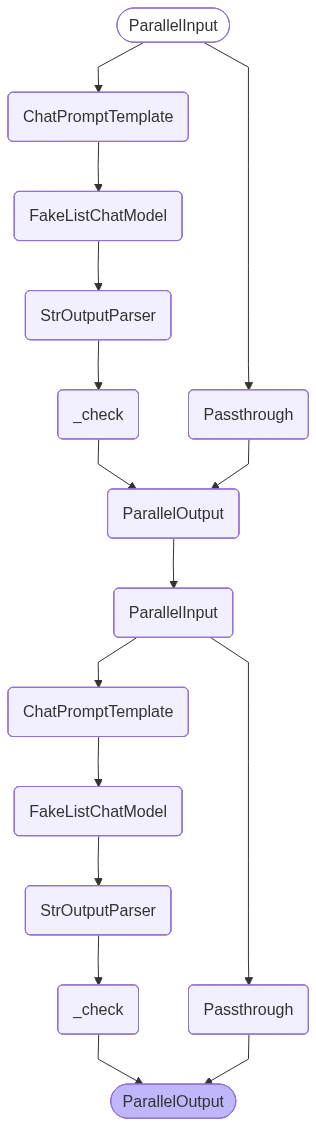

In [6]:
# Only the structure matters here, so any model works.
show_graph(build_pipeline(FakeListChatModel(responses=[REWRITE_REPLY, FACTCHECK_REPLY])),
           alt="Prompt Chaining graph")

## Bounded retry with `.with_retry()`

The gate raises `GateFailed`; `.with_retry(retry_if_exception_type=(GateFailed,), stop_after_attempt=N)` catches it and re-runs the *whole step* — re-rendering the prompt and re-calling the model — up to `N` attempts. That is the same bounded gated retry the langgraph version implements with a `max_retries` counter, but here it is one method call instead of a loop and a routing node.

This is also the cap on **gate tyranny**: if the gate is impossible to satisfy, the retries are exhausted and `GateFailed` propagates out instead of looping forever. The exception message carries the gate name and description, so the operator can see exactly which gate to loosen.

In [7]:
# A model that always returns output too short for a length>=200 gate, so the
# gate never passes — gate tyranny. FakeListChatModel cycles its one reply, so
# every retry attempt gets "too short" again.
tyrant_step = build_step(
    "[role]rewriter[/role] write a long paragraph",
    "Draft:\n{user_input}",
    length_gate(200, 2000),    # impossible for 'too short'
    FakeListChatModel(responses=["too short"]),
    max_retries=2,             # initial + 2 retries = 3 attempts
)

try:
    tyrant_step.invoke({"user_input": "hello"})
except GateFailed as e:
    print("GateFailed — retries exhausted, the chain gives up instead of looping forever:")
    print(f"  {e}")

GateFailed — retries exhausted, the chain gives up instead of looping forever:
  gate 'length[200-2000]' rejected output (output length between 200 and 2000 chars)


## Mock run — full pipeline, no API key

`RoleFakeChatModel` lets the whole two-step pipeline run deterministically. Each step's gate passes, each `.assign` adds a key, and the final dict holds both intermediate outputs. Watch the `factcheck` value: it confirms `35%` survived end to end — the bug from the lecture opening, fixed.

In [8]:
draft = (
    "q3 gmv grew 35% YoY, driven by cat 4 (3C) and cat 7 (apparel). "
    "active byuer count up 18%."   # intentional typo, like the lecture draft
)

# Two calls (rewrite, then factcheck) → the two replies in order.
mock_pipeline = build_pipeline(FakeListChatModel(responses=[REWRITE_REPLY, FACTCHECK_REPLY]))
result = mock_pipeline.invoke({"user_input": draft})

print("=" * 72)
print("Accumulated dict (every step's output, threaded forward)")
print("=" * 72)
for key, value in result.items():
    print(f"  {key:11s} -> {str(value)[:78]}")

print()
print("Information-starvation guard: factcheck saw both the original draft")
print("and the rewrite, so '35%' was verified against the source —")
print("not against a mutated rewrite.")

Accumulated dict (every step's output, threaded forward)
  user_input  -> q3 gmv grew 35% YoY, driven by cat 4 (3C) and cat 7 (apparel). active byuer co
  rewrite     -> In Q3, GMV expanded 35% YoY. The growth was led by 3C (category 4) and apparel
  factcheck   -> verified: numbers in the rewrite match the original draft (GMV 35%, active buy

Information-starvation guard: factcheck saw both the original draft
and the rewrite, so '35%' was verified against the source —
not against a mutated rewrite.


## Gate failure scenario

When a step's output can pass the gate on a *later* attempt, retry recovers and the pipeline continues. When it can never pass, the retries are exhausted and `GateFailed` surfaces — fail closed, with a message naming the gate.

Here the fact-checker buries its verdict in prose ("…everything is verified") instead of *leading* with it, so `starts_with_gate(["verified", "discrepancy"])` rejects it every time. The step exhausts its retries and raises — an unanchored verdict never reaches the rest of the chain.

In [9]:
# A factchecker that buries its verdict in prose instead of leading with it,
# so it never starts with 'verified'/'discrepancy' and fails the gate.
bad_factcheck = build_step(
    "[role]factchecker[/role] Begin with 'verified' or 'discrepancy'.",
    "Original:\n{user_input}\n\nRewrite:\n{user_input}",
    starts_with_gate(["verified", "discrepancy"]),
    FakeListChatModel(responses=["After comparing the numbers, everything is verified."]),
    max_retries=2,
)

try:
    bad_factcheck.invoke({"user_input": "q3 gmv +35%, buyers +18%"})
    print("unexpected: gate passed")
except GateFailed as e:
    print("Gate held the line — an unanchored verdict never flowed downstream:")
    print(f"  {e}")

Gate held the line — an unanchored verdict never flowed downstream:
  gate 'starts_with[verified,discrepancy]' rejected output (output must start with one of: ['verified', 'discrepancy'])


## Real backend

The exact same `build_pipeline` runs against the configured model. We guard with `if model:` so the cell is a no-op when no API key is set (the mock section above already proved the wiring). A real model is unpredictable, so we catch `GateFailed` — a real run can legitimately trip a gate — and report it instead of crashing the notebook.

In [10]:
if model:
    real_pipeline = build_pipeline(model)
    try:
        real_result = real_pipeline.invoke({"user_input": draft})
        print("=" * 72)
        print("Real pipeline output")
        print("=" * 72)
        for key, value in real_result.items():
            print(f"  {key:11s} -> {str(value)[:78]}")
    except GateFailed as e:
        # A real model can trip a gate; that is the pattern working, not a bug.
        print(f"A gate rejected real output after its retries: {e}")
    except Exception as e:
        print(f"Real model call failed ({type(e).__name__}): {e}")
else:
    print("No model configured — skipping real run. See .env.example to enable.")

Real pipeline output
  user_input  -> q3 gmv grew 35% YoY, driven by cat 4 (3C) and cat 7 (apparel). active byuer co
  rewrite     -> In Q3, GMV grew 35% year-over-year (YoY), driven by Category 4 (3C) and Catego
  factcheck   -> verified


## What to remember

- **The LCEL pipe *is* the chain.** `prompt | model | StrOutputParser() | gate` is one step; piping steps composes the pipeline. No graph, no node wiring.
- **A gate is a `RunnableLambda` that passes through or raises.** Wrapping it that way lets `.with_retry(retry_if_exception_type=(GateFailed,), stop_after_attempt=N)` give the same bounded gated retry the langgraph version codes by hand — and caps gate tyranny.
- **`RunnablePassthrough.assign` threads every prior output forward.** Each `.assign` adds one key to a running dict, so fact-check can read the *original* draft and the rewrite both. That is the information-starvation guard.
- **Less code than `StateGraph`, but the flow is implicit.** You trade the explicit, inspectable node graph for a terse pipe. Pick LCEL to ship fast; pick the graph when you need to see and debug every transition.
- **Gate raises = fail closed.** A rejected output stops the pipe; it never reaches the next step. A broken gate must not become an open pipe.

## Further reading

- [Graph version](../langgraph/tutorial.ipynb) — the same Prompt Chaining pattern as an explicit LangGraph `StateGraph`: one node per step, a gate node between steps, a manual `max_retries` loop, and the running state in a `TypedDict`
- [Parent pattern README](../README.md) — full design rationale, the two named failure modes (information starvation, gate tyranny), the gate-vs-step contract, and verified engineering references (Aider's recursive-summary chain, Claude Code's implicit PRA loop)
- [REFERENCE_IMPL.md](../../../REFERENCE_IMPL.md) — how to install `uv`, sync dependencies, launch JupyterLab, and run all tutorial notebooks
- [LangChain Expression Language (LCEL)](https://python.langchain.com/docs/concepts/lcel/) — the `Runnable` interface, the `|` pipe operator, and how `prompt | model | parser` composes
- [`Runnable.with_retry`](https://python.langchain.com/api_reference/core/runnables/langchain_core.runnables.base.Runnable.html#langchain_core.runnables.base.Runnable.with_retry) — bounded retry on selected exception types, the mechanism behind the gated retry here
- [`RunnablePassthrough.assign`](https://python.langchain.com/docs/how_to/passthrough/) — accumulate keys into a running dict so every step sees all prior outputs
- [Anthropic — *Building Effective Agents*](https://www.anthropic.com/research/building-effective-agents) — prompt chaining listed as the simplest, most under-used agent pattern: a small number of well-defined steps with gates between them